In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score


In [2]:
# Load Dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Spliting
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Train Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "SVM": SVR()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    results[name] = {"MSE": mse, "y_pred": y_pred}
    print(f"{name} MSE: {mse:.4f}")


Linear Regression MSE: 0.5559
Decision Tree MSE: 0.4952
Random Forest MSE: 0.2554
SVM MSE: 1.3320


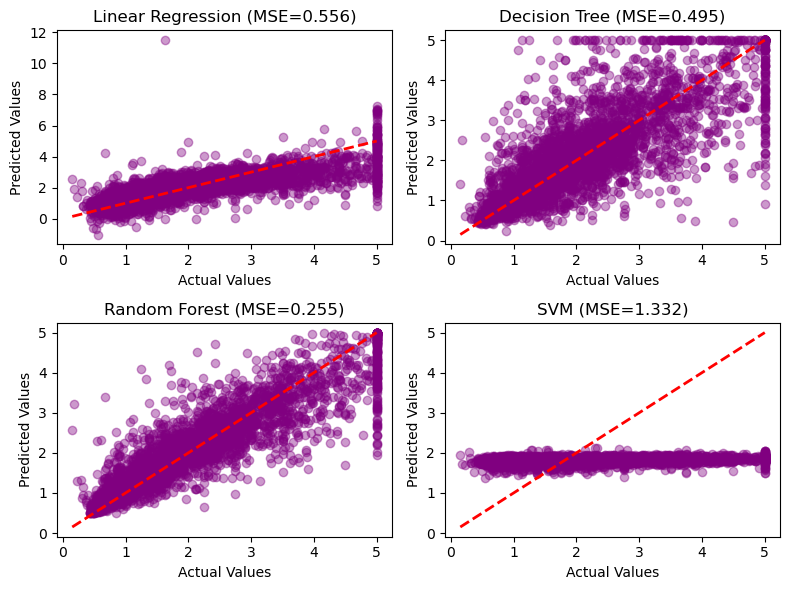

In [18]:
# Plot Graph
plt.figure(figsize=(8, 6))
for i, (name, res) in enumerate(results.items(), 1):
    plt.subplot(2, 2, i)
    plt.scatter(y_test, res["y_pred"], color='purple',alpha=0.4)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f"{name} (MSE={res['MSE']:.3f})")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()

In [8]:
# Convert target for binary for logistic regression
median_value = y.median()
y_binary = (y > median_value).astype(int)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y_binary, test_size=0.2, random_state=42)


In [9]:
# Train logistic Model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_b, y_train_b)
y_pred_log = log_reg.predict(X_test_b)

acc = accuracy_score(y_test_b, y_pred_log)
print(f"\nLogistic Regression Accuracy: {acc:.3f}")



Logistic Regression Accuracy: 0.817


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


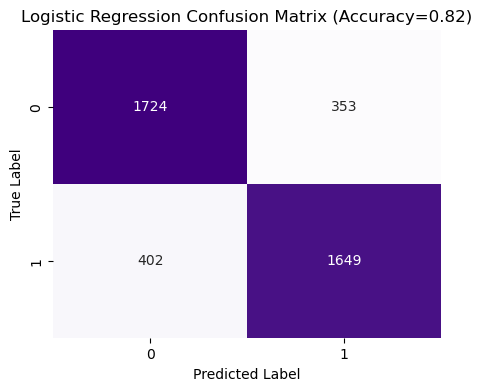

In [17]:
#Configure Matrix graph
cm = confusion_matrix(y_test_b, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title(f"Logistic Regression Confusion Matrix (Accuracy={acc:.2f})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()